In [20]:
import torch as t
import matplotlib.pyplot as plt

In [21]:
# How to represent numerical data in a computer?
# What are images?

In [22]:
#rgb values
black = (0, 0, 0)
red = (255, 0, 0)
blue = (0, 255, 0)
green = (0, 0, 255)

In [23]:
img = t.tensor(
    [
        [black, red],
        [blue, green]
    ]
)
img

tensor([[[  0,   0,   0],
         [255,   0,   0]],

        [[  0, 255,   0],
         [  0,   0, 255]]])

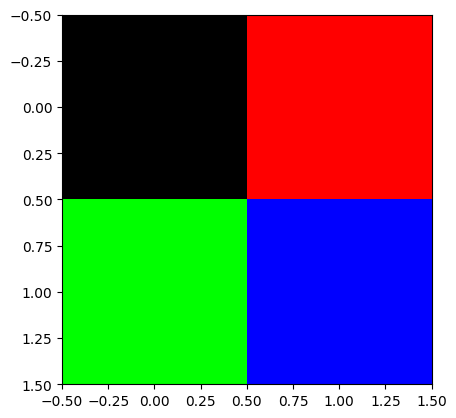

In [24]:
plt.imshow(img)
plt.show()

In [25]:
height = 256
width = 256
rand_img = t.randint(0, 256, (height, width, 3))
rand_img.shape

torch.Size([256, 256, 3])

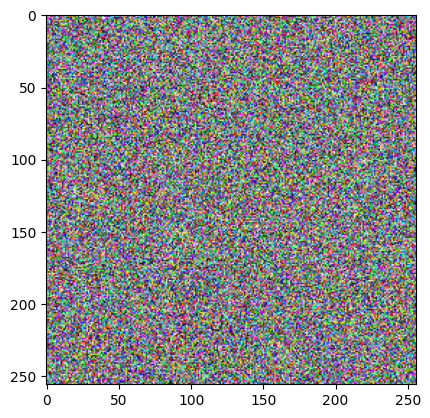

In [26]:
plt.imshow(rand_img)
plt.show()

In [27]:
# What are deep learning models? And how can they learn?

In [28]:
data = t.rand(100, 4)
target = t.rand(100, 1)

In [29]:
weight = t.rand(1, 4, requires_grad=True)
weight

tensor([[0.8959, 0.2654, 0.3358, 0.1330]], requires_grad=True)

In [30]:
def perceptron(data, target, weight):
    pred = (data * weight).sum(-1, keepdim=True)
    return ((pred - target) ** 2).mean()

In [31]:
lr = 0.01
def update(weight):
    weight = weight.detach() - lr * weight.grad.detach()
    weight.requires_grad=True
    return weight

In [32]:
lst = []
for i in range(1024):
    loss = perceptron(data, target, weight)
    loss.backward()
    weight = update(weight)
    lst.append(loss.item())

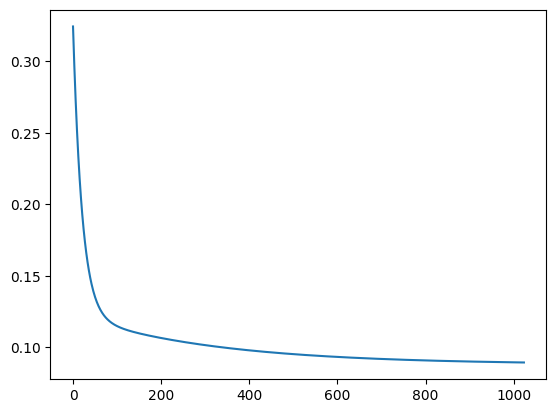

In [33]:
plt.plot(list(range(1024)), lst)
plt.show()